In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
    

In [3]:

PATH = "Data Model - Pizza Sales.csv"   

df = pd.read_csv(PATH, sep=",")
df.head()

,order_details_id,order_id,pizza_id,quantity,order_date,order_time,unit_price,total_price,pizza_size,pizza_category,pizza_ingredients,pizza_name
0,1,1,hawaiian_m,1,1/1/2015,11:38:36,13.25,13.25,M,Classic,"Sliced Ham, Pineapple, Mozzarella Cheese",The Hawaiian Pizza
1,2,2,classic_dlx_m,1,1/1/2015,11:57:40,16.00,16.00,M,Classic,"Pepperoni, Mushrooms, Red Onions, Red Peppers,...",The Classic Deluxe Pizza
2,3,2,five_cheese_l,1,1/1/2015,11:57:40,18.50,18.50,L,Veggie,"Mozzarella Cheese, Provolone Cheese, Smoked Go...",The Five Cheese Pizza
3,4,2,ital_supr_l,1,1/1/2015,11:57:40,20.75,20.75,L,Supreme,"Calabrese Salami, Capocollo, Tomatoes, Red Oni...",The Italian Supreme Pizza
4,5,2,mexicana_m,1,1/1/2015,11:57:40,16.00,16.00,M,Veggie,"Tomatoes, Red Peppers, Jalapeno Peppers, Red O...",The Mexicana Pizza


In [3]:

#combinging date time and also making col for hours/day
df["order_datetime"] = pd.to_datetime(
    df["order_date"] + " " + df["order_time"],
)
df["hour"] = df["order_datetime"].dt.hour
df["day_name"] = df["order_datetime"].dt.day_name()

df.head()


,order_details_id,order_id,pizza_id,quantity,order_date,order_time,unit_price,total_price,pizza_size,pizza_category,pizza_ingredients,pizza_name,order_datetime,hour,day_name
0,1,1,hawaiian_m,1,1/1/2015,11:38:36,13.25,13.25,M,Classic,"Sliced Ham, Pineapple, Mozzarella Cheese",The Hawaiian Pizza,2015-01-01 11:38:36,11,Thursday
1,2,2,classic_dlx_m,1,1/1/2015,11:57:40,16.00,16.00,M,Classic,"Pepperoni, Mushrooms, Red Onions, Red Peppers,...",The Classic Deluxe Pizza,2015-01-01 11:57:40,11,Thursday
2,3,2,five_cheese_l,1,1/1/2015,11:57:40,18.50,18.50,L,Veggie,"Mozzarella Cheese, Provolone Cheese, Smoked Go...",The Five Cheese Pizza,2015-01-01 11:57:40,11,Thursday
3,4,2,ital_supr_l,1,1/1/2015,11:57:40,20.75,20.75,L,Supreme,"Calabrese Salami, Capocollo, Tomatoes, Red Oni...",The Italian Supreme Pizza,2015-01-01 11:57:40,11,Thursday
4,5,2,mexicana_m,1,1/1/2015,11:57:40,16.00,16.00,M,Veggie,"Tomatoes, Red Peppers, Jalapeno Peppers, Red O...",The Mexicana Pizza,2015-01-01 11:57:40,11,Thursday


/var/folders/1h/zntg658s51n04lht0ylk3zyw0000gn/T/ipykernel_85232/2134082455.py:12: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  heat = df.pivot_table(index="day_name", columns="hour", values="order_id", aggfunc="count")


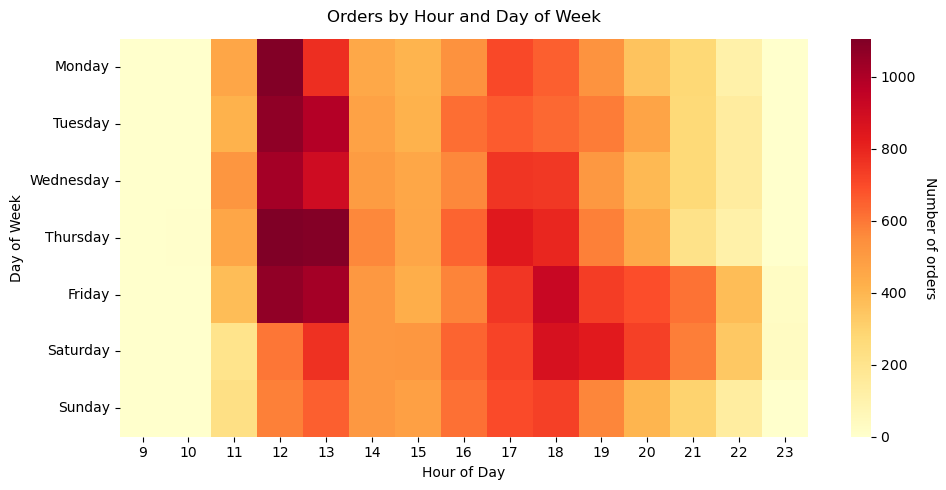

In [4]:

# Heatmap of orders by Hour and day of Week

# order categories s-xxl
size_order = ["S","M","L","XL","XXL"]
df["pizza_size"] = pd.Categorical(df["pizza_size"],categories=size_order, ordered=True)

# Order days Monday-Sunday
day_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
df["day_name"] = pd.Categorical(df["day_name"], categories=day_order, ordered=True)


heat = df.pivot_table(index="day_name", columns="hour", values="order_id", aggfunc="count")

plt.figure(figsize=(10, 5))
ax = sns.heatmap(heat, cmap="YlOrRd")
cbar = ax.collections[0].colorbar
cbar.set_label("Number of orders", rotation=270, labelpad=15)  # label the colorbar
ax.set_title("Orders by Hour and Day of Week", pad=12)
ax.set_xlabel("Hour of Day")
ax.set_ylabel("Day of Week")
plt.tight_layout()
plt.savefig(r"heatmap_orders.jpg")  # JPG

plt.show()


/var/folders/1h/zntg658s51n04lht0ylk3zyw0000gn/T/ipykernel_85232/3736129393.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  piv = df.groupby(["pizza_category", "pizza_size"])["total_price"].sum().unstack()


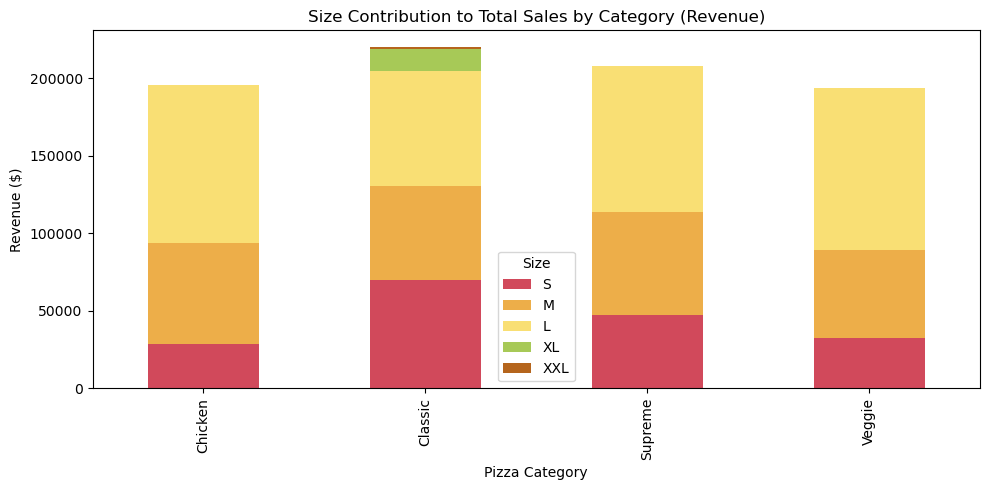

In [5]:

#Stacked Bar plot of Size Contribution to Total Sales by Category

# Group by category and size, and pivot
piv = df.groupby(["pizza_category", "pizza_size"])["total_price"].sum().unstack()

#stacked bars
piv.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 5),
    color=["#d1495b", "#edae49", "#f9df74", "#a7c957", "#b5651d"]

)

plt.title("Size Contribution to Total Sales by Category (Revenue)")
plt.ylabel("Revenue ($)")
plt.xlabel("Pizza Category")
plt.legend(title="Size")
plt.tight_layout()
plt.savefig(r"size_contribution_by_sales.jpg")  # JPG

plt.show()


/var/folders/1h/zntg658s51n04lht0ylk3zyw0000gn/T/ipykernel_85232/1547583902.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


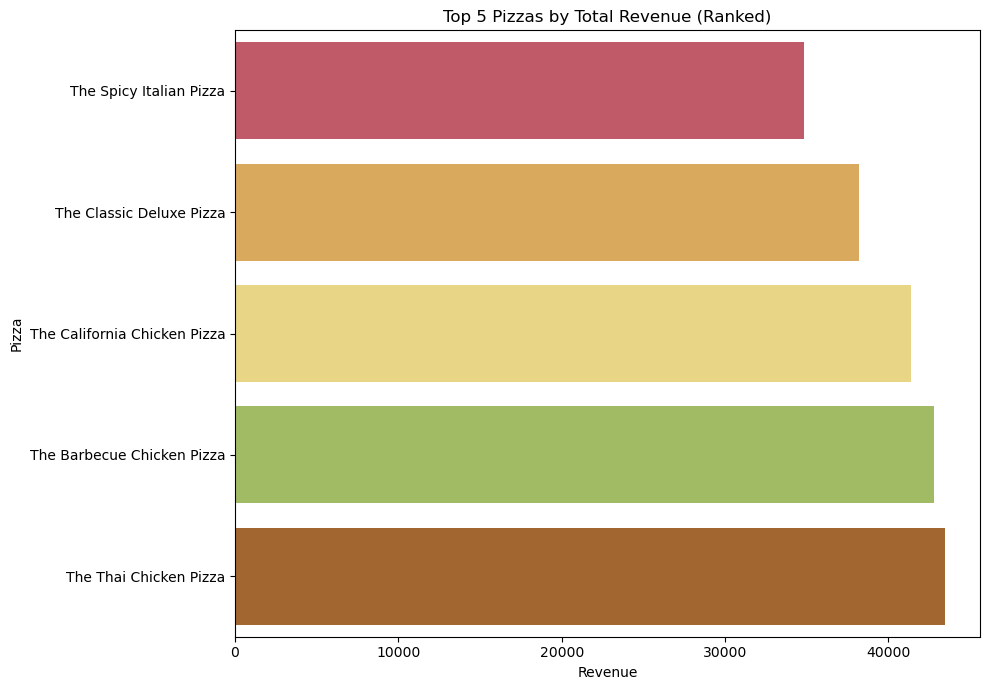

In [6]:
# Bar Chart of Top Pizzas by Total Revenue

topn = (df.groupby("pizza_name", as_index=False)["total_price"]
          .sum()
          .sort_values("total_price", ascending=True))

TOP_N = 5
top_slice = topn.tail(TOP_N)

pizza_colors = ["#d1495b", "#edae49", "#f9df74", "#a7c957", "#b5651d"]  # pizza palette

plt.figure(figsize=(10, 7))
ax = sns.barplot(
    data=top_slice,
    x="total_price",
    y="pizza_name",
    palette=pizza_colors
)
ax.set_title(f"Top {TOP_N} Pizzas by Total Revenue (Ranked)")
ax.set_xlabel("Revenue")
ax.set_ylabel("Pizza")
plt.tight_layout()
plt.savefig(r"top_pizza_by_revenue.jpg")  # JPG

plt.show()


In [ ]:
import altair as alt

df = pd.read_csv("pizza_ingredients_data.csv")


alt.data_transformers.disable_max_rows()


df["pizza_ingredients"] = df["pizza_ingredients"].fillna("")
df["pizza_ingredients"] = df["pizza_ingredients"].str.split(",")
ingredient_df = df.explode("pizza_ingredients").copy()
ingredient_df["ingredient"] = ingredient_df["pizza_ingredients"].str.strip()


df.to_csv("pizza_data.csv", index=False)
ingredient_df.to_csv("pizza_ingredients_data.csv", index=False)

brush = alt.selection_interval(encodings=["x"])

scatter = (
    alt.Chart("pizza_data.csv") 
    .mark_circle(size=60, opacity=0.6)
    .encode(
        x=alt.X("unit_price:Q", title="Unit Price ($)"),
        y=alt.Y("pizza_category:N", title="Category"),
        color=alt.Color(
            "pizza_category:N",
            title="Category",
            legend=None,
        ),
        tooltip=[
            "pizza_name:N",
            "pizza_size:N",
            "pizza_category:N",
            "unit_price:Q",
            "total_price:Q",
        ],
    )
    .add_params(brush)
    .properties(
        width=300,
        height=300,
        title="Unit Price by Pizza Category"
    )
)

bars = (
    alt.Chart("pizza_ingredients_data.csv") 
    .transform_filter(brush)
    .transform_aggregate(
        total_quantity="sum(quantity)",
        groupby=["ingredient"]
    )
    .transform_window(
        rank="rank(total_quantity)",
        sort=[alt.SortField("total_quantity", order="descending")]
    )
    .transform_filter("datum.rank <= 5")
    .mark_bar(color="#e8c827")   
    .encode(
        y=alt.Y("ingredient:N", sort="-x", title="Ingredient"),
        x=alt.X("total_quantity:Q", title="Total Pizzas Sold"),
        tooltip=[
            alt.Tooltip("ingredient:N", title="Ingredient"),
            alt.Tooltip("total_quantity:Q", title="Qty Ordered"),
        ],
    )
    .properties(
        width=300,
        height=300,
        title="Top 5 Ingredients"
    )
)

chart = scatter | bars
chart.save("pizza_unitprice_ingredients.html")
chart



HTML file size: 0.00 MB
✅ File size is good!

For the HTML to work on a website:
1. Upload these files to your web server:
   - pizza_unitprice_ingredients.html
   - pizza_data.csv
   - pizza_ingredients_data.csv
2. They must be in the same directory
